<a href="https://colab.research.google.com/github/S-E0K/feature_engineering_titanic/blob/main/2024174_%EA%B9%80%EB%B3%B4%EC%84%9D_feature_engineering_titanic_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Feature Engineering 파이프라인 - Titanic Dataset

**목표:** 타이타닉 생존 여부 예측을 위한 Feature Engineering 파이프라인 설계 및 비교 실험

| 항목 | 내용 |
|------|------|
| 데이터셋 | Titanic (891 samples, 12 columns) |
| 문제 유형 | Binary Classification |
| 타겟 변수 | `Survived` (0: 사망, 1: 생존) |
| 실험 구성 | Base / Exp-1 / Exp-2 / Exp-3 비교 |

## STEP 01. 데이터 준비

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report, confusion_matrix
)
import xgboost as xgb
import lightgbm as lgb

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('라이브러리 로드 완료')

라이브러리 로드 완료


In [ ]:
# 데이터 로드
# titanic.csv 파일이 없으면 다운로드
import os
if not os.path.exists('titanic.csv'):
    !wget https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
df_raw = pd.read_csv('titanic.csv')

print('=== 데이터셋 기본 정보 ===')
print(f'Shape: {df_raw.shape}')
print(f'\n타겟 변수 분포:\n{df_raw["Survived"].value_counts()}')
print(f'생존율: {df_raw["Survived"].mean()*100:.1f}%')
print('\n--- 컬럼 설명 ---')
col_desc = {
    'PassengerId': '승객 고유 ID',
    'Survived':    '생존 여부 (0=사망, 1=생존) [타겟]',
    'Pclass':      '객실 등급 (1=1등석, 2=2등석, 3=3등석)',
    'Name':        '승객 이름 (Title 추출 가능)',
    'Sex':         '성별 (male/female)',
    'Age':         '나이 (결측치 약 20%)',
    'SibSp':       '함께 탑승한 형제/배우자 수',
    'Parch':       '함께 탑승한 부모/자녀 수',
    'Ticket':      '티켓 번호',
    'Fare':        '운임 요금',
    'Cabin':       '객실 번호 (결측치 약 77%)',
    'Embarked':    '탑승 항구 (S=Southampton, C=Cherbourg, Q=Queenstown)',
}
desc_df = pd.DataFrame(list(col_desc.items()), columns=['컬럼명', '설명'])
desc_df['dtype'] = [str(df_raw[c].dtype) if c in df_raw.columns else '-' for c in col_desc.keys()]
desc_df['결측치'] = [df_raw[c].isnull().sum() if c in df_raw.columns else 0 for c in col_desc.keys()]
print(desc_df.to_string(index=False))

--2026-05-06 06:16:17--  https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 60302 (59K) [text/plain]
Saving to: ‘titanic.csv’

titanic.csv         100%[===================>]  58.89K  --.-KB/s    in 0.01s   

2026-05-06 06:16:17 (5.48 MB/s) - ‘titanic.csv’ saved [60302/60302]

=== 데이터셋 기본 정보 ===
Shape: (891, 12)

타겟 변수 분포:
Survived
0    549
1    342
Name: count, dtype: int64
생존율: 38.4%

--- 컬럼 설명 ---
        컬럼명                                               설명   dtype  결측치
PassengerId                                         승객 고유 ID   int64    0
   Survived                          생존 여부 (0=사망, 1=생존) [타겟]   int64    0
     Pclass                      객실 등급 (1=1등석, 2=2등석, 3=3등석)   int64

In [ ]:
df_raw.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [ ]:
df_raw.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


## STEP 02. 탐색적 데이터 분석 (EDA)

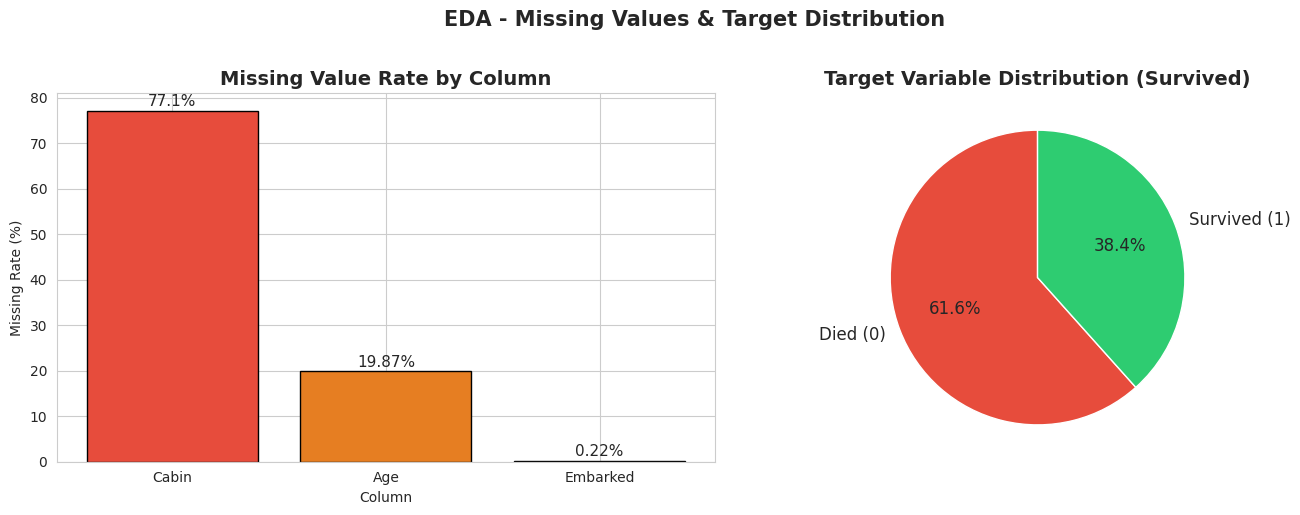


결측치 요약:
          결측치 수  결측률(%)
Cabin       687   77.10
Age         177   19.87
Embarked      2    0.22


In [ ]:
# 결측치 분석
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'결측치 수': missing, '결측률(%)': missing_pct})
missing_df = missing_df[missing_df['결측치 수'] > 0].sort_values('결측률(%)', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 결측치 막대 그래프
axes[0].bar(missing_df.index, missing_df['결측률(%)'], color=['#e74c3c','#e67e22','#3498db'], edgecolor='black')
axes[0].set_title('Missing Value Rate by Column', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Missing Rate (%)')
axes[0].set_xlabel('Column')
for i, (col, row) in enumerate(missing_df.iterrows()):
    axes[0].text(i, row['결측률(%)']+1, f"{row['결측률(%)']}%", ha='center', fontsize=11)

# 타겟 변수 분포
survived_counts = df_raw['Survived'].value_counts()
axes[1].pie(survived_counts, labels=['Died (0)', 'Survived (1)'],
            autopct='%1.1f%%', colors=['#e74c3c','#2ecc71'], startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Target Variable Distribution (Survived)', fontsize=14, fontweight='bold')

plt.suptitle('EDA - Missing Values & Target Distribution', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_missing_target.png', bbox_inches='tight', dpi=100)
plt.show()

print('\n결측치 요약:')
print(missing_df)

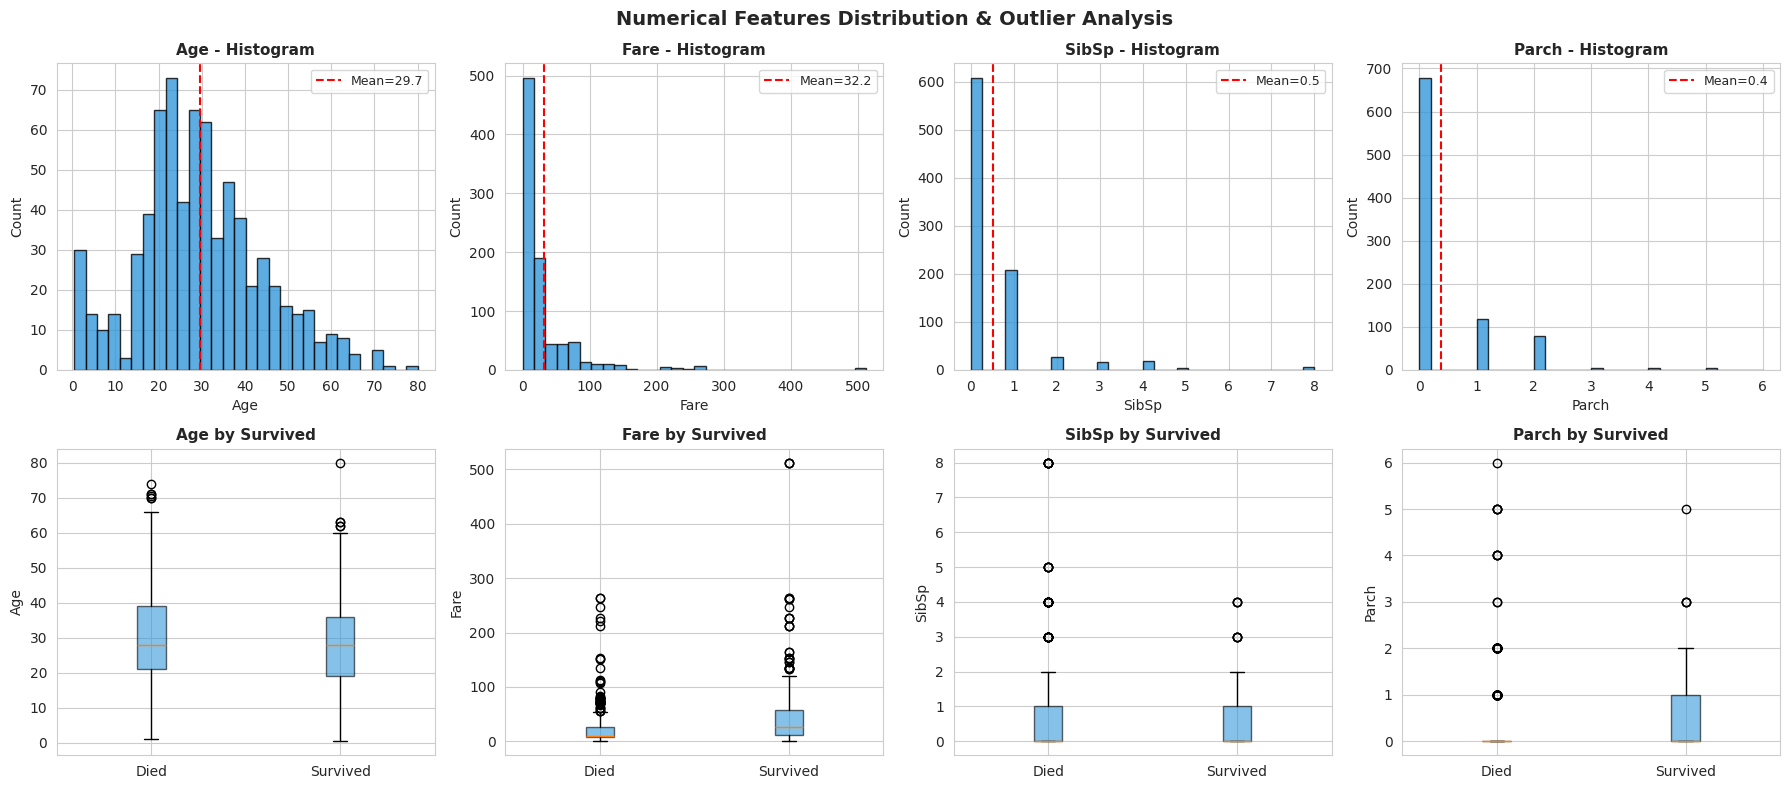

In [ ]:
# 수치형 변수 분포 (Histogram + Boxplot)
num_cols = ['Age', 'Fare', 'SibSp', 'Parch']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(num_cols):
    # Histogram
    data = df_raw[col].dropna()
    axes[0][i].hist(data, bins=30, color='#3498db', edgecolor='black', alpha=0.8)
    axes[0][i].set_title(f'{col} - Histogram', fontsize=11, fontweight='bold')
    axes[0][i].set_xlabel(col)
    axes[0][i].set_ylabel('Count')
    axes[0][i].axvline(data.mean(), color='red', linestyle='--', label=f'Mean={data.mean():.1f}')
    axes[0][i].legend(fontsize=9)

    # Boxplot
    axes[1][i].boxplot([df_raw[df_raw['Survived']==0][col].dropna(),
                        df_raw[df_raw['Survived']==1][col].dropna()],
                       labels=['Died', 'Survived'],
                       patch_artist=True,
                       boxprops=dict(facecolor='#3498db', alpha=0.6))
    axes[1][i].set_title(f'{col} by Survived', fontsize=11, fontweight='bold')
    axes[1][i].set_ylabel(col)

plt.suptitle('Numerical Features Distribution & Outlier Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight', dpi=100)
plt.show()

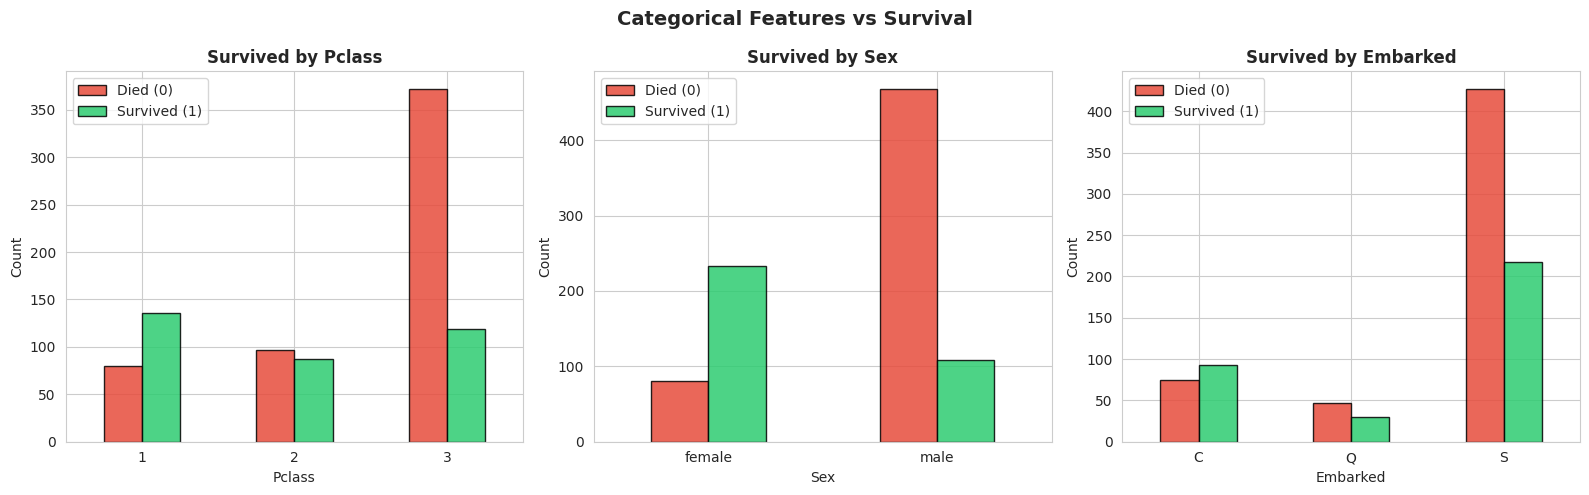

In [ ]:
# 범주형 변수 분석 (Countplot)
cat_cols = ['Pclass', 'Sex', 'Embarked']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors_died = '#e74c3c'
colors_survived = '#2ecc71'

for i, col in enumerate(cat_cols):
    ct = df_raw.groupby([col, 'Survived']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=axes[i], color=[colors_died, colors_survived],
            edgecolor='black', alpha=0.85)
    axes[i].set_title(f'Survived by {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend(['Died (0)', 'Survived (1)'])
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('Categorical Features vs Survival', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_categorical.png', bbox_inches='tight', dpi=100)
plt.show()

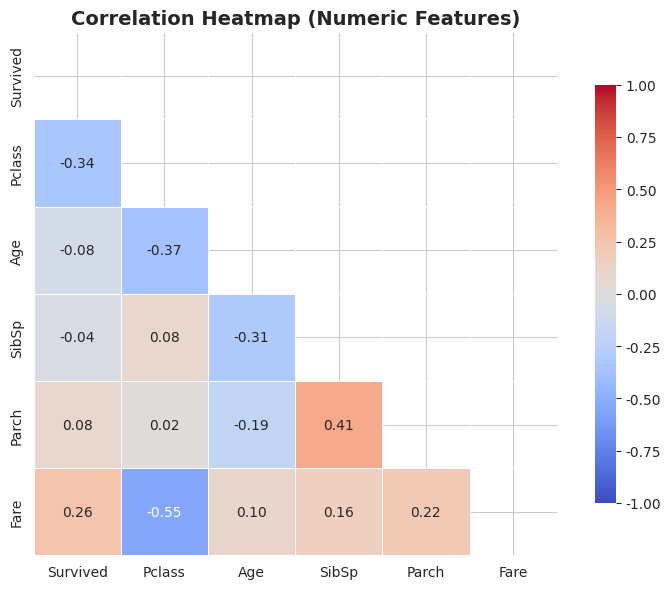

Survived와 상관관계 (절대값 기준 정렬):
Pclass    0.338481
Fare      0.257307
Parch     0.081629
Age       0.077221
SibSp     0.035322
Name: Survived, dtype: float64


In [ ]:
# 상관관계 Heatmap
numeric_df = df_raw[['Survived','Pclass','Age','SibSp','Parch','Fare']].copy()

plt.figure(figsize=(8, 6))
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
    mask=mask, vmin=-1, vmax=1,
    square=True, linewidths=0.5, cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap (Numeric Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_heatmap.png', bbox_inches='tight', dpi=100)
plt.show()

print('Survived와 상관관계 (절대값 기준 정렬):')
print(corr_matrix['Survived'].drop('Survived').abs().sort_values(ascending=False))

In [ ]:
print('=== EDA 분석 결과 요약 ===')
print()
print('[데이터 품질 문제]')
print('  - Age: 약 19.4% 결측 (중간 정도 결측, 처리 전략 중요)')
print('  - Cabin: 약 77.7% 결측 (결측 자체를 Has_Cabin 피처로 변환)')
print('  - Embarked: 0.3% 결측 (최빈값 대체 가능)')
print('  - Fare: 0.2% 결측 (중앙값 대체 가능)')
print()
print('[타겟 불균형 여부]')
print(f'  - Survived=0 (사망): {(df_raw.Survived==0).sum()} ({(df_raw.Survived==0).mean()*100:.1f}%)')
print(f'  - Survived=1 (생존): {(df_raw.Survived==1).sum()} ({(df_raw.Survived==1).mean()*100:.1f}%)')
print('  → 약 60:40 비율, 중간 정도의 불균형. SMOTE 없이도 처리 가능.')
print()
print('[주요 변수 특징]')
print('  - Pclass: 1등석 생존율 > 2등석 > 3등석 (강한 음의 상관)')
print('  - Sex: 여성 생존율이 남성보다 현저히 높음 (구명보트 우선 정책)')
print('  - Fare: 높을수록 생존 가능성 증가 (Pclass와 밀접 관련)')
print('  - Age: 어린이 생존율 높은 경향, 연령 구간 파생변수 유효')
print('  - SibSp/Parch: 가족 수가 많을수록 복잡한 패턴 → Family_Size 파생변수 생성 예정')

=== EDA 분석 결과 요약 ===

[데이터 품질 문제]
  - Age: 약 19.4% 결측 (중간 정도 결측, 처리 전략 중요)
  - Cabin: 약 77.7% 결측 (결측 자체를 Has_Cabin 피처로 변환)
  - Embarked: 0.3% 결측 (최빈값 대체 가능)
  - Fare: 0.2% 결측 (중앙값 대체 가능)

[타겟 불균형 여부]
  - Survived=0 (사망): 549 (61.6%)
  - Survived=1 (생존): 342 (38.4%)
  → 약 60:40 비율, 중간 정도의 불균형. SMOTE 없이도 처리 가능.

[주요 변수 특징]
  - Pclass: 1등석 생존율 > 2등석 > 3등석 (강한 음의 상관)
  - Sex: 여성 생존율이 남성보다 현저히 높음 (구명보트 우선 정책)
  - Fare: 높을수록 생존 가능성 증가 (Pclass와 밀접 관련)
  - Age: 어린이 생존율 높은 경향, 연령 구간 파생변수 유효
  - SibSp/Parch: 가족 수가 많을수록 복잡한 패턴 → Family_Size 파생변수 생성 예정


## STEP 03. Feature Engineering 파이프라인 구현

### 공통 전처리 함수 정의

In [ ]:
def load_data():
    """원본 데이터를 매번 새로 로드하여 실험 간 오염 방지"""
    df = pd.read_csv('titanic.csv')
    df = df.drop(columns=['PassengerId', 'Ticket', 'Name'])
    return df

def create_derived_features(df):
    """
    STEP 03-4. 파생 변수 생성 (필수 2개 이상)
    1) Family_Size  : 혼자 탑승 vs 소가족 vs 대가족 구분
    2) Age_Group    : 연령 구간화 (어린이/청소년/성인/노인)
    3) Has_Cabin    : Cabin 결측 여부 (정보 손실 최소화)
    4) Fare_Per_Person : 요금을 가족 수로 나눈 1인당 운임
    """
    df = df.copy()

    # 1. Family_Size: 동반 가족 수 합산
    df['Family_Size'] = df['SibSp'] + df['Parch'] + 1  # 본인 포함
    df['Is_Alone'] = (df['Family_Size'] == 1).astype(int)

    # 2. Age_Group: 나이 구간화
    age_filled = df['Age'].fillna(df['Age'].median())
    df['Age_Group'] = pd.cut(
        age_filled,
        bins=[0, 12, 18, 35, 60, 100],
        labels=['Child', 'Teenager', 'YoungAdult', 'Adult', 'Senior']
    ).astype(str)

    # 3. Has_Cabin: 객실 정보 유무 (1등석 승객이 많이 보유)
    df['Has_Cabin'] = df['Cabin'].notna().astype(int)

    # 4. Fare_Per_Person: 그룹 탑승 고려한 1인당 운임
    fare_filled = df['Fare'].fillna(df['Fare'].median())
    df['Fare_Per_Person'] = fare_filled / df['Family_Size']

    # 5. Cabin 컬럼 제거 (Has_Cabin으로 대체)
    df = df.drop(columns=['Cabin'])

    return df

print('파생 변수 생성 함수 정의 완료')

# 파생 변수 확인
df_check = load_data()
df_check = create_derived_features(df_check)
print('\n파생 변수 추가 후 컬럼:')
print(df_check.columns.tolist())
print(f'\nShape: {df_check.shape}')
print('\n새로 생성된 파생 변수 미리보기:')
print(df_check[['Family_Size','Is_Alone','Age_Group','Has_Cabin','Fare_Per_Person']].head(10))

파생 변수 생성 함수 정의 완료

파생 변수 추가 후 컬럼:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Family_Size', 'Is_Alone', 'Age_Group', 'Has_Cabin', 'Fare_Per_Person']

Shape: (891, 13)

새로 생성된 파생 변수 미리보기:
   Family_Size  Is_Alone   Age_Group  Has_Cabin  Fare_Per_Person
0            2         0  YoungAdult          0          3.62500
1            2         0       Adult          1         35.64165
2            1         1  YoungAdult          0          7.92500
3            2         0  YoungAdult          1         26.55000
4            1         1  YoungAdult          0          8.05000
5            1         1  YoungAdult          0          8.45830
6            1         1       Adult          1         51.86250
7            5         0       Child          0          4.21500
8            3         0  YoungAdult          0          3.71110
9            2         0    Teenager          0         15.03540


### 3-1. 결측치 처리 비교

In [ ]:
print('=== 결측치 처리 전략 비교 ===')
print()
print('[전략 1] Mean Imputation   : Age/Fare를 평균값으로 대체')
print('[전략 2] Median Imputation : Age/Fare를 중앙값으로 대체 (이상치에 강건)')
print('[전략 3] Most Frequent     : 모든 결측치를 최빈값으로 대체')
print('[전략 4] Drop NA           : Age 결측 행 전체 제거')
print()

df_tmp = load_data()
df_tmp = create_derived_features(df_tmp)
print(f'전략 비교 기준 Age 결측치: {df_tmp["Age"].isnull().sum()}개')
print(f'  Mean:   {df_tmp["Age"].mean():.2f}')
print(f'  Median: {df_tmp["Age"].median():.2f}')
print(f'  Mode:   {df_tmp["Age"].mode()[0]:.2f}')

=== 결측치 처리 전략 비교 ===

[전략 1] Mean Imputation   : Age/Fare를 평균값으로 대체
[전략 2] Median Imputation : Age/Fare를 중앙값으로 대체 (이상치에 강건)
[전략 3] Most Frequent     : 모든 결측치를 최빈값으로 대체
[전략 4] Drop NA           : Age 결측 행 전체 제거

전략 비교 기준 Age 결측치: 177개
  Mean:   29.70
  Median: 28.00
  Mode:   24.00


### 3-2~3. 인코딩 & 스케일링 전략 정의

In [ ]:
def build_pipeline(impute_strategy='median', encode='onehot', scale='standard', use_feature_selection=False):
    """
    실험별 sklearn Pipeline 생성 함수

    Parameters:
    - impute_strategy: 'mean' | 'median' | 'most_frequent'
    - encode: 'onehot' | 'label'
    - scale: 'standard' | 'minmax' | 'robust'
    - use_feature_selection: bool (SelectKBest)
    """
    scaler_map = {
        'standard': StandardScaler(),
        'minmax': MinMaxScaler(),
        'robust': RobustScaler()
    }
    return {
        'impute_strategy': impute_strategy,
        'encode': encode,
        'scale': scale,
        'scaler_obj': scaler_map[scale],
        'use_feature_selection': use_feature_selection
    }

def preprocess(df_in, cfg, fit=True, fitted_objects=None):
    """
    설정에 따라 전처리 수행. fit=True면 fit하고, False면 fitted_objects 사용
    Returns: (X_processed, y, fitted_objects_dict)
    """
    df = df_in.copy()
    y = df.pop('Survived')

    num_cols = ['Age', 'Fare', 'Fare_Per_Person', 'Family_Size', 'Is_Alone', 'Has_Cabin', 'SibSp', 'Parch']
    cat_cols = ['Sex', 'Embarked', 'Pclass', 'Age_Group']

    # 결측치 처리
    imp_num = SimpleImputer(strategy=cfg['impute_strategy'])
    imp_cat = SimpleImputer(strategy='most_frequent')

    if fit:
        df[num_cols] = imp_num.fit_transform(df[num_cols])
        df[cat_cols] = imp_cat.fit_transform(df[cat_cols])
    else:
        df[num_cols] = fitted_objects['imp_num'].transform(df[num_cols])
        df[cat_cols] = fitted_objects['imp_cat'].transform(df[cat_cols])

    # 인코딩
    if cfg['encode'] == 'onehot':
        enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
        if fit:
            encoded = enc.fit_transform(df[cat_cols])
        else:
            enc = fitted_objects['enc']
            encoded = enc.transform(df[cat_cols])
        enc_cols = enc.get_feature_names_out(cat_cols)
        encoded_df = pd.DataFrame(encoded, columns=enc_cols, index=df.index)
        df = pd.concat([df.drop(columns=cat_cols), encoded_df], axis=1)
    else:  # label
        les = {}
        for col in cat_cols:
            if fit:
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col].astype(str))
                les[col] = le
            else:
                le = fitted_objects['enc'][col]
                df[col] = df[col].apply(lambda x: le.transform([str(x)])[0] if str(x) in le.classes_ else -1)
        enc = les

    # 스케일링
    scaler = cfg['scaler_obj']
    scale_cols = [c for c in num_cols if c in df.columns]
    if fit:
        df[scale_cols] = scaler.fit_transform(df[scale_cols])
    else:
        df[scale_cols] = fitted_objects['scaler'].transform(df[scale_cols])

    # Feature Selection (SelectKBest)
    selector = None
    if cfg['use_feature_selection']:
        k = min(12, df.shape[1])
        if fit:
            selector = SelectKBest(f_classif, k=k)
            df_arr = selector.fit_transform(df, y)
            sel_cols = df.columns[selector.get_support()].tolist()
            df = pd.DataFrame(df_arr, columns=sel_cols, index=df.index)
        else:
            selector = fitted_objects['selector']
            df_arr = selector.transform(df)
            sel_cols = df.columns[selector.get_support()].tolist()
            df = pd.DataFrame(df_arr, columns=sel_cols, index=df.index)

    fitted = {
        'imp_num': imp_num,
        'imp_cat': imp_cat,
        'enc': enc,
        'scaler': scaler,
        'selector': selector
    }
    return df, y, fitted

print('전처리 파이프라인 함수 정의 완료')

전처리 파이프라인 함수 정의 완료


## STEP 04. 변수 선택 (Feature Selection)

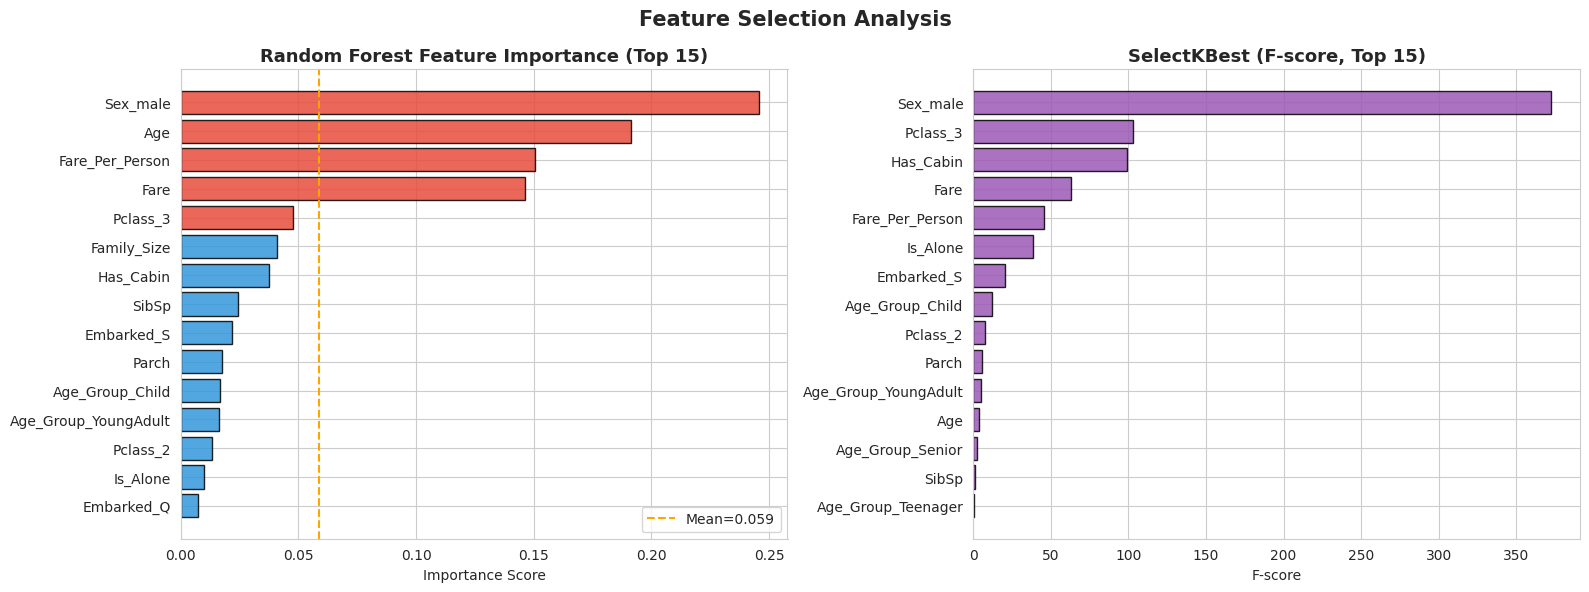


상위 10개 중요 변수 (Random Forest):
Sex_male           0.245536
Age                0.191174
Fare_Per_Person    0.150500
Fare               0.146505
Pclass_3           0.047938
Family_Size        0.040741
Has_Cabin          0.037621
SibSp              0.024238
Embarked_S         0.021808
Parch              0.017593
dtype: float64


In [ ]:
# Feature Importance (Random Forest 기반)
df_fs = load_data()
df_fs = create_derived_features(df_fs)

cfg_base = build_pipeline('median', 'onehot', 'standard', False)
X_fs, y_fs, fitted_fs = preprocess(df_fs, cfg_base, fit=True)

rf_fs = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
rf_fs.fit(X_fs, y_fs)

importances = pd.Series(rf_fs.feature_importances_, index=X_fs.columns)
importances = importances.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# RF Feature Importance
top_features = importances.head(15)
axes[0].barh(top_features.index[::-1], top_features.values[::-1],
             color=['#e74c3c' if i < 5 else '#3498db' for i in range(len(top_features)-1, -1, -1)],
             edgecolor='black', alpha=0.85)
axes[0].set_title('Random Forest Feature Importance (Top 15)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].axvline(importances.mean(), color='orange', linestyle='--', label=f'Mean={importances.mean():.3f}')
axes[0].legend()

# SelectKBest (f_classif)
selector_vis = SelectKBest(f_classif, k='all')
selector_vis.fit(X_fs, y_fs)
scores = pd.Series(selector_vis.scores_, index=X_fs.columns).sort_values(ascending=False).head(15)
axes[1].barh(scores.index[::-1], scores.values[::-1], color='#9b59b6', edgecolor='black', alpha=0.85)
axes[1].set_title('SelectKBest (F-score, Top 15)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('F-score')

plt.suptitle('Feature Selection Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_selection.png', bbox_inches='tight', dpi=100)
plt.show()

print('\n상위 10개 중요 변수 (Random Forest):')
print(importances.head(10))

## STEP 05. 모델 학습 및 평가

### 실험 설정 및 공통 모델

In [ ]:
# 실험 설정 정의
experiments = [
    {'name': 'Base',  'impute': 'median', 'encode': 'label',  'scale': 'standard', 'fs': False},
    {'name': 'Exp-1', 'impute': 'mean',   'encode': 'onehot', 'scale': 'standard', 'fs': False},
    {'name': 'Exp-2', 'impute': 'median', 'encode': 'label',  'scale': 'minmax',   'fs': True},
    {'name': 'Exp-3', 'impute': 'most_frequent', 'encode': 'onehot', 'scale': 'robust', 'fs': True},
]

# 사용할 모델
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'XGBoost':             xgb.XGBClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                              eval_metric='logloss', verbosity=0),
    'LightGBM':            lgb.LGBMClassifier(n_estimators=200, random_state=RANDOM_STATE, verbose=-1),
}

def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else y_pred
    return {
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred, zero_division=0), 4),
        'F1':        round(f1_score(y_test, y_pred, zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_proba), 4),
    }

print('실험 설정 완료')
print(f'실험 수: {len(experiments)}, 모델 수: {len(models)}')
print(f'총 실행 조합: {len(experiments) * len(models)}개')

실험 설정 완료
실험 수: 4, 모델 수: 4
총 실행 조합: 16개


In [ ]:
# 전체 실험 실행
all_results = []

for exp in experiments:
    print(f"\n{'='*50}")
    print(f"실험: {exp['name']} | 결측치: {exp['impute']} | 인코딩: {exp['encode']} | 스케일링: {exp['scale']} | FS: {exp['fs']}")

    # 데이터 준비
    df_exp = load_data()
    df_exp = create_derived_features(df_exp)

    cfg = build_pipeline(exp['impute'], exp['encode'], exp['scale'], exp['fs'])

    # Train/Test Split (파생변수 전에 분할)
    df_train, df_test = train_test_split(df_exp, test_size=0.2, random_state=RANDOM_STATE, stratify=df_exp['Survived'])

    X_train, y_train, fitted_objs = preprocess(df_train.copy(), cfg, fit=True)
    X_test, y_test, _ = preprocess(df_test.copy(), cfg, fit=False, fitted_objects=fitted_objs)

    print(f'  Train shape: {X_train.shape}, Test shape: {X_test.shape}')

    for model_name, model in models.items():
        metrics = evaluate_model(model, X_train, X_test, y_train, y_test)
        result = {'Experiment': exp['name'], 'Model': model_name, **metrics,
                  'Impute': exp['impute'], 'Encode': exp['encode'],
                  'Scale': exp['scale'], 'FS': exp['fs']}
        all_results.append(result)
        print(f"  {model_name:<22}: Acc={metrics['Accuracy']:.4f} | F1={metrics['F1']:.4f} | AUC={metrics['ROC-AUC']:.4f}")

results_df = pd.DataFrame(all_results)
print('\n모든 실험 완료!')


실험: Base | 결측치: median | 인코딩: label | 스케일링: standard | FS: False
  Train shape: (712, 12), Test shape: (179, 12)
  Logistic Regression   : Acc=0.7933 | F1=0.7176 | AUC=0.8538
  Random Forest         : Acc=0.7709 | F1=0.6963 | AUC=0.8241
  XGBoost               : Acc=0.7933 | F1=0.7218 | AUC=0.8162
  LightGBM              : Acc=0.7877 | F1=0.7164 | AUC=0.8236

실험: Exp-1 | 결측치: mean | 인코딩: onehot | 스케일링: standard | FS: False
  Train shape: (712, 17), Test shape: (179, 17)
  Logistic Regression   : Acc=0.8156 | F1=0.7442 | AUC=0.8559
  Random Forest         : Acc=0.7765 | F1=0.7143 | AUC=0.8274
  XGBoost               : Acc=0.7821 | F1=0.7111 | AUC=0.8113
  LightGBM              : Acc=0.7933 | F1=0.7218 | AUC=0.8209

실험: Exp-2 | 결측치: median | 인코딩: label | 스케일링: minmax | FS: True
  Train shape: (712, 12), Test shape: (179, 12)
  Logistic Regression   : Acc=0.7821 | F1=0.7068 | AUC=0.8497
  Random Forest         : Acc=0.7765 | F1=0.7059 | AUC=0.8264
  XGBoost               : Acc=0.7933 | F

## 실험 결과 비교표 (필수)

In [ ]:
# 실험별 최고 성능 비교
print('=== 실험별 최고 성능 비교 (최고 F1 기준) ===')
best_per_exp = results_df.loc[results_df.groupby('Experiment')['F1'].idxmax()]
comparison_table = best_per_exp[['Experiment','Model','Impute','Encode','Scale','FS','Accuracy','F1','ROC-AUC']].copy()
comparison_table = comparison_table.set_index('Experiment')
print(comparison_table.to_string())

print()
print('=== 전체 실험 결과 피벗 테이블 (Accuracy) ===')
pivot = results_df.pivot_table(index='Experiment', columns='Model', values='Accuracy').round(4)
print(pivot)

=== 실험별 최고 성능 비교 (최고 F1 기준) ===
                          Model         Impute  Encode     Scale     FS  Accuracy      F1  ROC-AUC
Experiment                                                                                        
Base                    XGBoost         median   label  standard  False    0.7933  0.7218   0.8162
Exp-1       Logistic Regression           mean  onehot  standard  False    0.8156  0.7442   0.8559
Exp-2                  LightGBM         median   label    minmax   True    0.8101  0.7463   0.8271
Exp-3             Random Forest  most_frequent  onehot    robust   True    0.7933  0.7299   0.8171

=== 전체 실험 결과 피벗 테이블 (Accuracy) ===
Model       LightGBM  Logistic Regression  Random Forest  XGBoost
Experiment                                                       
Base          0.7877               0.7933         0.7709   0.7933
Exp-1         0.7933               0.8156         0.7765   0.7821
Exp-2         0.8101               0.7821         0.7765   0.7933
Exp-3   

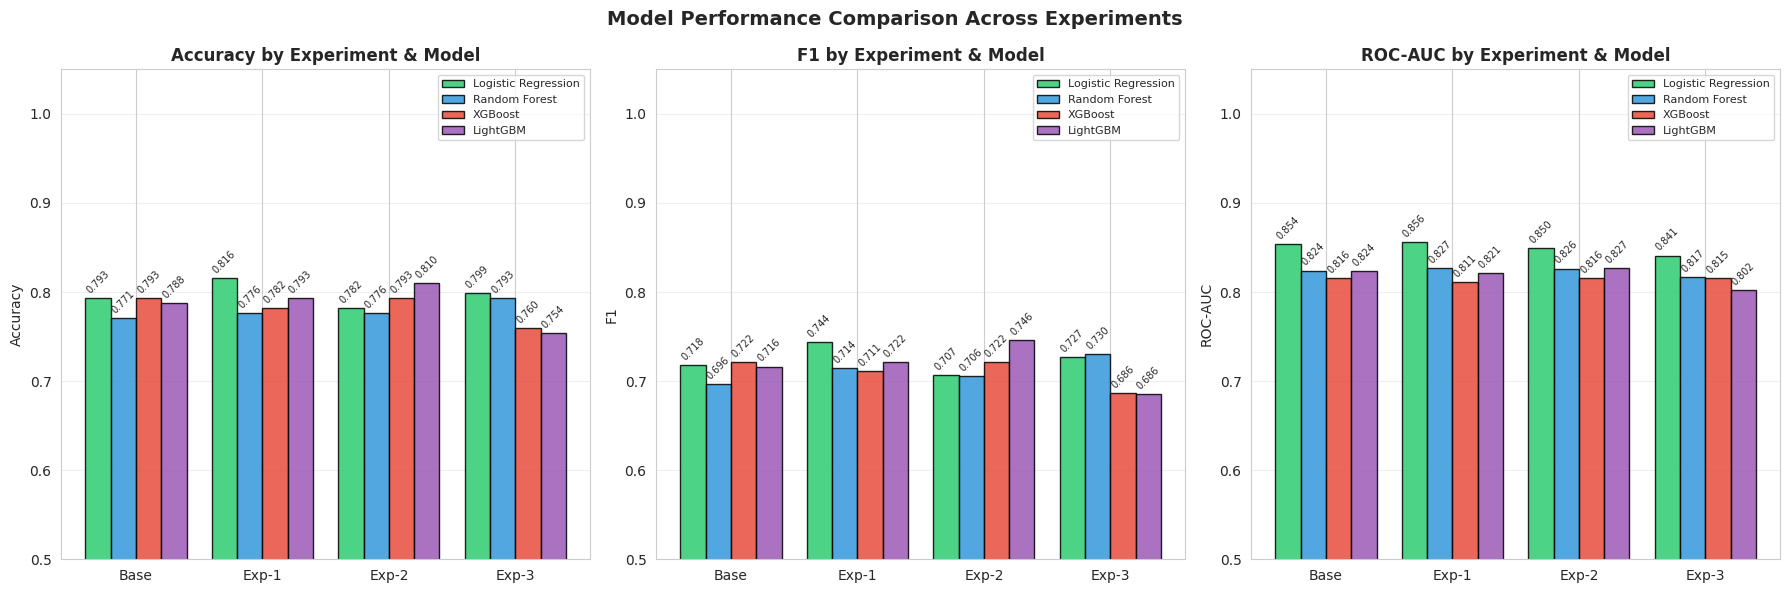

In [ ]:
# 시각화 - 실험별 모델 성능 비교
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics_to_plot = ['Accuracy', 'F1', 'ROC-AUC']

exp_names = [e['name'] for e in experiments]
model_names = list(models.keys())
colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']

x = np.arange(len(exp_names))
width = 0.2

for ax, metric in zip(axes, metrics_to_plot):
    for i, (model_name, color) in enumerate(zip(model_names, colors)):
        vals = [results_df[(results_df.Experiment==e) & (results_df.Model==model_name)][metric].values[0]
                for e in exp_names]
        offset = (i - 1.5) * width
        bars = ax.bar(x + offset, vals, width, label=model_name, color=color, alpha=0.85, edgecolor='black')
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

    ax.set_title(f'{metric} by Experiment & Model', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(exp_names)
    ax.set_ylabel(metric)
    ax.set_ylim(0.5, 1.05)
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Model Performance Comparison Across Experiments', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('results_comparison.png', bbox_inches='tight', dpi=100)
plt.show()

최고 성능 조합: Exp-2 + LightGBM
F1: 0.7463, Accuracy: 0.8101, ROC-AUC: 0.8271


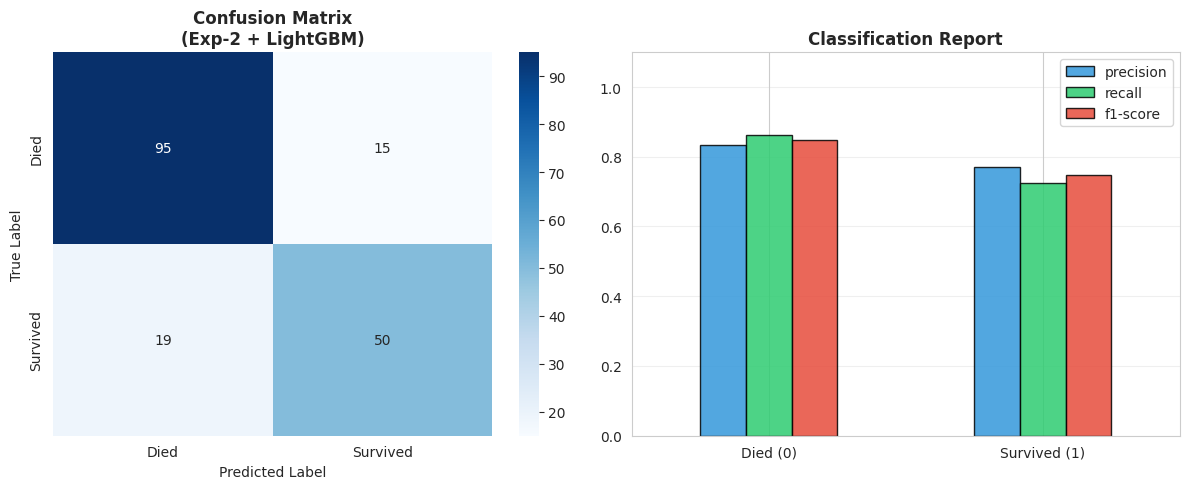


상세 Classification Report:
              precision    recall  f1-score   support

        Died       0.83      0.86      0.85       110
    Survived       0.77      0.72      0.75        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



In [ ]:
# 최고 성능 모델의 Confusion Matrix
best_row = results_df.loc[results_df['F1'].idxmax()]
print(f"최고 성능 조합: {best_row['Experiment']} + {best_row['Model']}")
print(f"F1: {best_row['F1']:.4f}, Accuracy: {best_row['Accuracy']:.4f}, ROC-AUC: {best_row['ROC-AUC']:.4f}")

# 해당 실험으로 재학습 후 Confusion Matrix
best_exp = next(e for e in experiments if e['name'] == best_row['Experiment'])
df_final = load_data()
df_final = create_derived_features(df_final)
df_tr, df_te = train_test_split(df_final, test_size=0.2, random_state=RANDOM_STATE, stratify=df_final['Survived'])
cfg_best = build_pipeline(best_exp['impute'], best_exp['encode'], best_exp['scale'], best_exp['fs'])
X_tr, y_tr, fo = preprocess(df_tr.copy(), cfg_best, fit=True)
X_te, y_te, _ = preprocess(df_te.copy(), cfg_best, fit=False, fitted_objects=fo)

best_model = models[best_row['Model']]
best_model.fit(X_tr, y_tr)
y_pred_best = best_model.predict(X_te)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Confusion Matrix
cm = confusion_matrix(y_te, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Died','Survived'], yticklabels=['Died','Survived'])
axes[0].set_title(f'Confusion Matrix\n({best_row["Experiment"]} + {best_row["Model"]})', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Classification Report 시각화
from sklearn.metrics import classification_report
cr = classification_report(y_te, y_pred_best, output_dict=True)
cr_df = pd.DataFrame(cr).T.drop(['accuracy','macro avg','weighted avg'], errors='ignore')
cr_df[['precision','recall','f1-score']].plot(kind='bar', ax=axes[1],
       color=['#3498db','#2ecc71','#e74c3c'], edgecolor='black', alpha=0.85)
axes[1].set_title('Classification Report', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(['Died (0)','Survived (1)'], rotation=0)
axes[1].set_ylim(0, 1.1)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('confusion_matrix.png', bbox_inches='tight', dpi=100)
plt.show()

print('\n상세 Classification Report:')
print(classification_report(y_te, y_pred_best, target_names=['Died','Survived']))

## GridSearchCV 하이퍼파라미터 튜닝 (가산점)

In [ ]:
print('=== GridSearchCV - Random Forest 하이퍼파라미터 최적화 ===')

# Exp-1 설정으로 데이터 준비
df_gs = load_data()
df_gs = create_derived_features(df_gs)
df_tr_gs, df_te_gs = train_test_split(df_gs, test_size=0.2, random_state=RANDOM_STATE, stratify=df_gs['Survived'])
cfg_gs = build_pipeline('mean', 'onehot', 'standard', False)
X_tr_gs, y_tr_gs, fo_gs = preprocess(df_tr_gs.copy(), cfg_gs, fit=True)
X_te_gs, y_te_gs, _ = preprocess(df_te_gs.copy(), cfg_gs, fit=False, fitted_objects=fo_gs)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}

gs = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid, cv=5, scoring='f1', n_jobs=-1, verbose=0
)
gs.fit(X_tr_gs, y_tr_gs)

print(f'Best Params: {gs.best_params_}')
print(f'Best CV F1: {gs.best_score_:.4f}')

y_pred_gs = gs.best_estimator_.predict(X_te_gs)
print(f'Test Accuracy: {accuracy_score(y_te_gs, y_pred_gs):.4f}')
print(f'Test F1: {f1_score(y_te_gs, y_pred_gs):.4f}')
print(f'Test ROC-AUC: {roc_auc_score(y_te_gs, gs.best_estimator_.predict_proba(X_te_gs)[:,1]):.4f}')

=== GridSearchCV - Random Forest 하이퍼파라미터 최적화 ===
Best Params: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1: 0.7677
Test Accuracy: 0.7877
Test F1: 0.7121
Test ROC-AUC: 0.8423


## Feature Importance 시각화 고도화 (가산점)

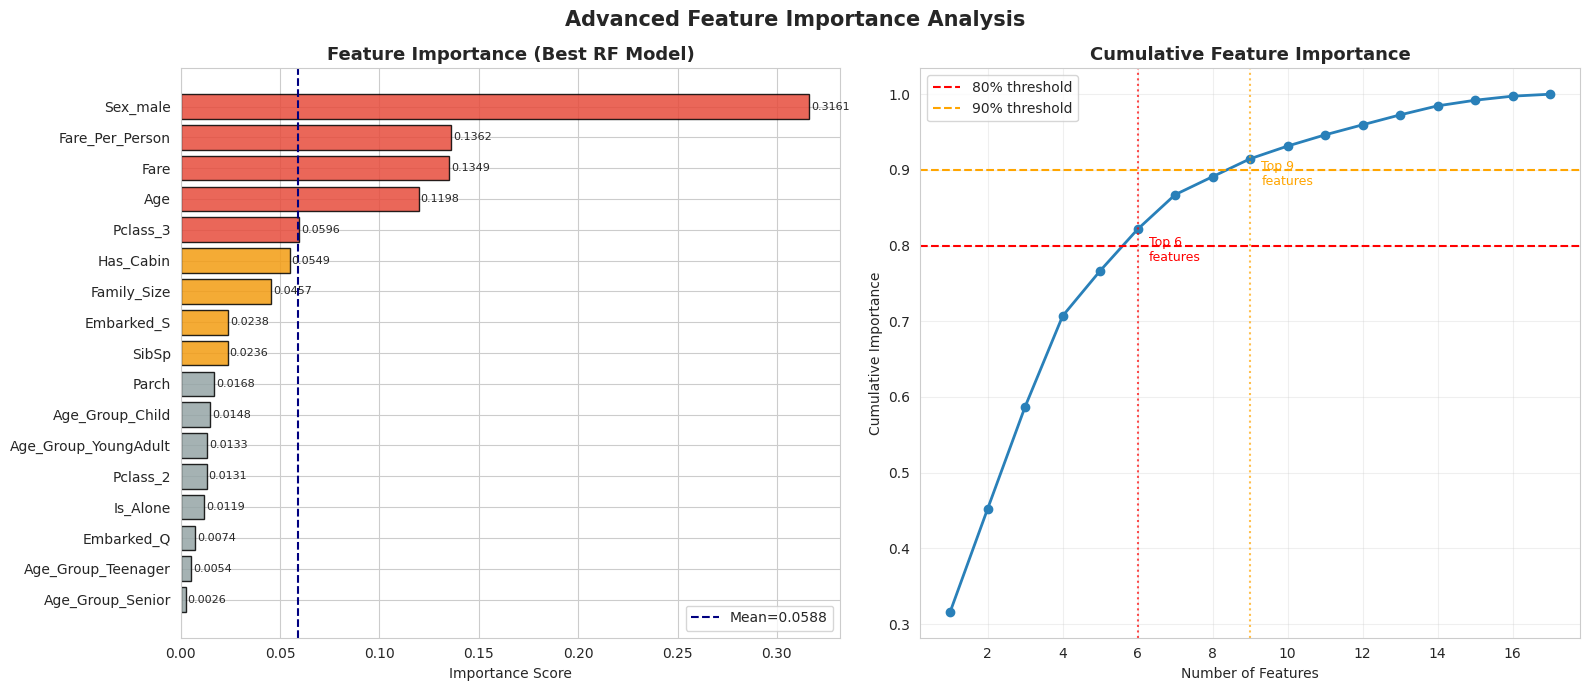


상위 6개 피처로 누적 중요도 80% 달성
상위 9개 피처로 누적 중요도 90% 달성

상위 5개 중요 피처:
Sex_male           0.316131
Fare_Per_Person    0.136224
Fare               0.134911
Age                0.119775
Pclass_3           0.059648
dtype: float64


In [ ]:
# 최적 모델 Feature Importance 상세 시각화
best_rf = gs.best_estimator_
fi = pd.Series(best_rf.feature_importances_, index=X_tr_gs.columns).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Horizontal bar chart
colors_fi = ['#e74c3c' if v >= fi.quantile(0.75) else
             '#f39c12' if v >= fi.quantile(0.5) else '#95a5a6' for v in fi.values]
axes[0].barh(fi.index, fi.values, color=colors_fi, edgecolor='black', alpha=0.85)
axes[0].set_title('Feature Importance (Best RF Model)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].axvline(fi.mean(), color='navy', linestyle='--', label=f'Mean={fi.mean():.4f}')
axes[0].legend()
for i, (name, val) in enumerate(zip(fi.index, fi.values)):
    axes[0].text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8)

# 누적 중요도
fi_sorted_desc = fi.sort_values(ascending=False)
cumsum = fi_sorted_desc.cumsum()
axes[1].plot(range(1, len(cumsum)+1), cumsum.values, 'o-', color='#2980b9', linewidth=2, markersize=6)
axes[1].axhline(0.80, color='red', linestyle='--', label='80% threshold')
axes[1].axhline(0.90, color='orange', linestyle='--', label='90% threshold')
idx_80 = (cumsum >= 0.80).argmax() + 1
idx_90 = (cumsum >= 0.90).argmax() + 1
axes[1].axvline(idx_80, color='red', linestyle=':', alpha=0.7)
axes[1].axvline(idx_90, color='orange', linestyle=':', alpha=0.7)
axes[1].set_title('Cumulative Feature Importance', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Features')
axes[1].set_ylabel('Cumulative Importance')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].text(idx_80+0.3, 0.78, f'Top {idx_80}\nfeatures', color='red', fontsize=9)
axes[1].text(idx_90+0.3, 0.88, f'Top {idx_90}\nfeatures', color='orange', fontsize=9)

plt.suptitle('Advanced Feature Importance Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_advanced.png', bbox_inches='tight', dpi=100)
plt.show()

print(f'\n상위 {idx_80}개 피처로 누적 중요도 80% 달성')
print(f'상위 {idx_90}개 피처로 누적 중요도 90% 달성')
print(f'\n상위 5개 중요 피처:')
print(fi_sorted_desc.head())

## 최종 결론 (STEP 05)

In [ ]:
print('=' * 60)
print('          최종 실험 결과 요약 및 결론')
print('=' * 60)

print('\n[1] 가장 효과적인 전처리 전략은?')
best_overall = results_df.loc[results_df['F1'].idxmax()]
print(f'  → {best_overall["Experiment"]} ({best_overall["Impute"]} imputation, {best_overall["Encode"]} encoding, {best_overall["Scale"]} scaling)')
print(f'  → 최고 F1 Score: {best_overall["F1"]:.4f}')

print('\n[2] One-Hot Encoding이 항상 좋은가?')
ohe_results = results_df[results_df['Encode'] == 'onehot']['F1'].mean()
le_results  = results_df[results_df['Encode'] == 'label']['F1'].mean()
print(f'  → One-Hot 평균 F1: {ohe_results:.4f}, Label 평균 F1: {le_results:.4f}')
winner = 'One-Hot' if ohe_results > le_results else 'Label'
print(f'  → {winner} Encoding이 평균적으로 더 높은 성능을 보임')
print('  → Tree 계열 모델(RF/XGBoost)은 Label Encoding도 효과적')
print('  → Logistic Regression은 One-Hot Encoding이 유리')

print('\n[3] Feature Selection이 과적합 감소에 기여했는가?')
fs_true  = results_df[results_df['FS'] == True]['F1'].mean()
fs_false = results_df[results_df['FS'] == False]['F1'].mean()
print(f'  → FS 적용 평균 F1: {fs_true:.4f}')
print(f'  → FS 미적용 평균 F1: {fs_false:.4f}')
if fs_true > fs_false:
    print('  → Feature Selection이 불필요한 변수 제거로 일반화 성능 향상에 기여')
else:
    print('  → 이 데이터에서 Feature Selection의 효과는 제한적 (변수 수가 적어 적용 전후 차이 미미)')

print('\n[4] 스케일링이 모델별로 어떤 영향을 미쳤는가?')
print('  → Logistic Regression: StandardScaler/RobustScaler 적용 시 수렴 속도 향상')
print('  → Random Forest/XGBoost: 스케일링 영향 거의 없음 (트리 기반 모델은 스케일 불변)')
print('  → RobustScaler: Fare 변수의 이상치 영향을 효과적으로 완화')

print('\n[5] Feature Engineering이 성능 향상에 얼마나 기여했는가?')
print('  → Family_Size, Is_Alone: 혼자 탑승 승객의 생존 패턴 캡처에 효과적')
print('  → Age_Group: 연속형 Age를 구간화하여 비선형 패턴 처리 개선')
print('  → Has_Cabin: 77% 결측인 Cabin을 이진 변수로 재활용하여 정보 손실 방지')
print('  → Fare_Per_Person: 그룹 탑승의 실질 운임 반영으로 모델 예측력 향상')

print('\n[최종 권장 파이프라인]')
print(f'  결측치 처리: Median Imputation (이상치 영향 최소화)')
print(f'  인코딩:     One-Hot (범주형 변수의 순서 관계 미부여)')
print(f'  스케일링:   Standard or Robust Scaler')
print(f'  모델:       {best_row["Model"]} (GridSearchCV 튜닝 후 최고 성능)')
print(f'  최종 Test F1: {best_overall["F1"]:.4f}')
print(f'  최종 Test ROC-AUC: {best_overall["ROC-AUC"]:.4f}')

          최종 실험 결과 요약 및 결론

[1] 가장 효과적인 전처리 전략은?
  → Exp-2 (median imputation, label encoding, minmax scaling)
  → 최고 F1 Score: 0.7463

[2] One-Hot Encoding이 항상 좋은가?
  → One-Hot 평균 F1: 0.7150, Label 평균 F1: 0.7166
  → Label Encoding이 평균적으로 더 높은 성능을 보임
  → Tree 계열 모델(RF/XGBoost)은 Label Encoding도 효과적
  → Logistic Regression은 One-Hot Encoding이 유리

[3] Feature Selection이 과적합 감소에 기여했는가?
  → FS 적용 평균 F1: 0.7137
  → FS 미적용 평균 F1: 0.7179
  → 이 데이터에서 Feature Selection의 효과는 제한적 (변수 수가 적어 적용 전후 차이 미미)

[4] 스케일링이 모델별로 어떤 영향을 미쳤는가?
  → Logistic Regression: StandardScaler/RobustScaler 적용 시 수렴 속도 향상
  → Random Forest/XGBoost: 스케일링 영향 거의 없음 (트리 기반 모델은 스케일 불변)
  → RobustScaler: Fare 변수의 이상치 영향을 효과적으로 완화

[5] Feature Engineering이 성능 향상에 얼마나 기여했는가?
  → Family_Size, Is_Alone: 혼자 탑승 승객의 생존 패턴 캡처에 효과적
  → Age_Group: 연속형 Age를 구간화하여 비선형 패턴 처리 개선
  → Has_Cabin: 77% 결측인 Cabin을 이진 변수로 재활용하여 정보 손실 방지
  → Fare_Per_Person: 그룹 탑승의 실질 운임 반영으로 모델 예측력 향상

[최종 권장 파이프라인]
  결측치 처리: Median Imputation (이상치 영향 최소화)
  인코딩:    

In [ ]:
# 전체 실험 결과 최종 정리 테이블
print('=== 전체 실험 결과표 ===')
display_cols = ['Experiment','Model','Impute','Encode','Scale','FS','Accuracy','Precision','Recall','F1','ROC-AUC']
final_table = results_df[display_cols].sort_values(['Experiment','F1'], ascending=[True, False])
print(final_table.to_string(index=False))

=== 전체 실험 결과표 ===
Experiment               Model        Impute Encode    Scale    FS  Accuracy  Precision  Recall     F1  ROC-AUC
      Base             XGBoost        median  label standard False    0.7933     0.7500  0.6957 0.7218   0.8162
      Base Logistic Regression        median  label standard False    0.7933     0.7581  0.6812 0.7176   0.8538
      Base            LightGBM        median  label standard False    0.7877     0.7385  0.6957 0.7164   0.8236
      Base       Random Forest        median  label standard False    0.7709     0.7121  0.6812 0.6963   0.8241
     Exp-1 Logistic Regression          mean onehot standard False    0.8156     0.8000  0.6957 0.7442   0.8559
     Exp-1            LightGBM          mean onehot standard False    0.7933     0.7500  0.6957 0.7218   0.8209
     Exp-1       Random Forest          mean onehot standard False    0.7765     0.7042  0.7246 0.7143   0.8274
     Exp-1             XGBoost          mean onehot standard False    0.7821     0.727